## Expérimentation de modèles

In [3]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.experimental import enable_halving_search_cv
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import (
    Lasso, LassoCV,
    Ridge, LinearRegression
)
from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    GridSearchCV,
    learning_curve,
    HalvingGridSearchCV
)
from sklearn.metrics import mean_squared_error, median_absolute_error, r2_score, get_scorer_names

In [4]:
train_data = pd.read_csv("../data/processed_dataset.csv")
test_data = pd.read_parquet("../data/test_data.parquet")

X_train = train_data.drop(
    ["LoyerMensuel_Log1", "LoyerMensuel_BIF", "IdentifiantMaison"],
    axis=1).select_dtypes(include=["number"])
y_train = train_data["LoyerMensuel_Log1"]

print(X_train)

     Chambres  Superficie_m2  DistanceRoute_m  AgeMaison  Salon_Bin  \
0         1.0           46.0            154.0       20.0          1   
1         4.0          217.0            211.0       23.0          1   
2         4.0          181.0             64.0       24.0          1   
3         6.0          253.0            255.0        2.0          1   
4         3.0          162.0             29.0       34.0          1   
..        ...            ...              ...        ...        ...   
377       4.0          183.0            213.0       14.0          1   
378       6.0          171.0            250.0       34.0          1   
379       5.0          223.0            293.0       16.0          1   
380       6.0          287.0             24.0       30.0          1   
381       6.0          272.0            235.0       31.0          1   

     SalleDeBainInterieure_Bin  Parking_Bin  Meuble_Bin  Jardin_Bin  \
0                            1            0           0           0   
1    

### Transformation de données de test

In [5]:
# Les variables numériques
feature_cols = ["AgeMaison", "Quartier_Target", "Indicateur_Confort", "Chambres_par_Superficie", "LoyerMensuel_Log1"]

for col in ['Salon', 'SalleDeBainInterieure', 'Parking', 'Meuble', 'Jardin']:
    test_data[col + "_Bin"] = test_data[col].map({"Oui": 1, "Non": 0}).fillna(0).astype(int)

neighbourhood_encoder = joblib.load("neighbourhood_encoder.joblib") 
test_data["Quartier_Target"] = neighbourhood_encoder.transform(test_data[["Quartier"]])[:, 0]

test_data["LoyerMensuel_Log1"] = np.log1p(test_data["LoyerMensuel_BIF"])

# Création de variables utiles pour le test
# cols_confort = ['Salon_Bin', 'SalleDeBainInterieure_Bin', 'Parking_Bin', 'Meuble_Bin', 'Jardin_Bin']
# test_data['Indicateur_Confort'] = test_data[cols_confort].sum(axis=1)

# test_data['Chambres_par_Superficie'] = test_data['Chambres'] / (test_data['Superficie_m2'] + 0.1)

# Séparation de X_test et y_test
X_test = test_data.drop(
    ["LoyerMensuel_Log1", "LoyerMensuel_BIF", "IdentifiantMaison"],
    axis=1).select_dtypes(include=["number"])
y_test = test_data["LoyerMensuel_Log1"]

X_test

,Chambres,Superficie_m2,DistanceRoute_m,AgeMaison,Salon_Bin,SalleDeBainInterieure_Bin,Parking_Bin,Meuble_Bin,Jardin_Bin,Quartier_Target
0,1.0,46.0,154.0,20.0,1,1,0,0,0,0.010428
1,4.0,217.0,211.0,23.0,1,1,0,0,0,0.002128
2,4.0,181.0,64.0,24.0,1,1,1,0,0,0.002182
3,6.0,253.0,255.0,2.0,1,1,0,0,1,0.001636
4,3.0,162.0,29.0,34.0,1,1,1,1,0,0.001636
...,...,...,...,...,...,...,...,...,...,...
377,4.0,183.0,213.0,14.0,1,1,0,0,1,0.002163
378,6.0,171.0,250.0,34.0,1,1,0,0,0,0.001636
379,5.0,223.0,293.0,16.0,1,1,0,0,1,0.002061
380,6.0,287.0,24.0,30.0,1,1,1,0,1,0.001636


In [6]:
def formated_time(second):
    m, s = divmod(second, 60)

    if m > 0:
         f"{int(m)} min {s:.4f} secondes"
    else:
        return f"{s:.4f} secondes"

scoring = ["neg_mean_squared_error", "neg_median_absolute_error", "neg_root_mean_squared_error", "r2"]

In [14]:
def _learning_curve(model, model_name, X=X_train, y=y_train):

    train_sizes, train_scores, test_scores = learning_curve(
        estimator=model,
        X=X, y=y,
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=10,
        scoring="neg_mean_squared_error",
        n_jobs=-1,
        random_state=40
    )

    train_mean = -train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    test_mean = -test_scores.mean(axis=1)
    test_std = test_scores.std(axis=1)
    
    plt.figure(figsize=(10, 6))
    
    plt.plot(train_sizes, train_mean, "o-", color="red", label="Erreur d'entrainenement")
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="red")
    
    plt.plot(train_sizes, test_mean, "o-", color="blue", label="Erreur de validation")
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="blue")
    
    plt.title(f"Courbe d'Apprentissage (Learning Curve) - {model_name}")
    plt.xlabel("Nombre d'exemples d'entraînement")
    plt.ylabel("Erreur Quadratique Moyenne (MSE)")
    plt.legend(loc='best')
    plt.grid(True)
    
    plt.show()

### Modèle de Régression Linéaire

Fit Time : [0.01114583 0.00616717 0.00427294 0.00415158 0.0041995 ]

Score Time : [0.01342773 0.00608349 0.00473809 0.00497198 0.00745058]

Test Neg Median Abosulte Error : [-0.29193164 -0.33508889 -0.31824578 -0.24118789 -0.3432502 ]

Test Neg Mean Squared Error : [-0.28048846 -0.19495255 -0.19231695 -0.14773481 -0.16391579]

Test R2 : [0.38511628 0.60438951 0.39594465 0.5010853  0.51968459]


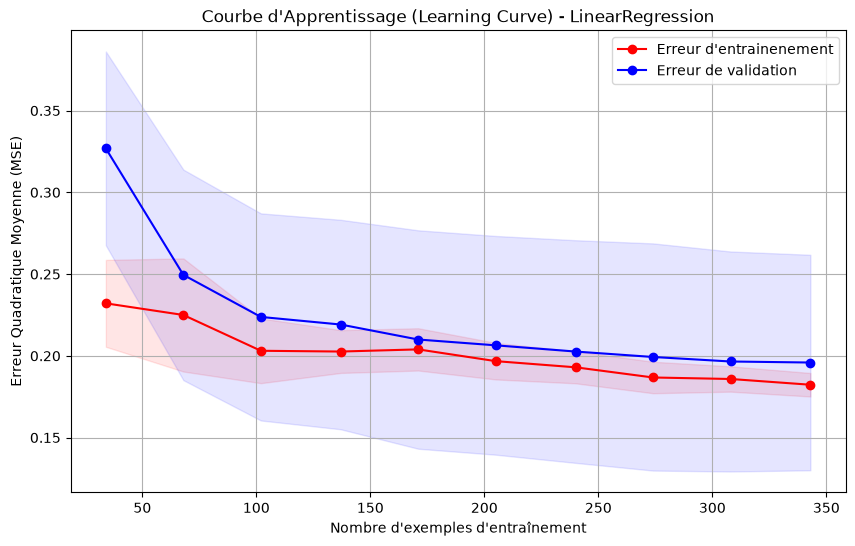

In [15]:
linear_model = LinearRegression()

linear_scores = cross_validate(linear_model, X_train, y_train, scoring=scoring)

print(f"Fit Time : {linear_scores["fit_time"]}")
print()
print(f"Score Time : {linear_scores["score_time"]}")
print()
print(f"Test Neg Median Abosulte Error : {linear_scores["test_neg_median_absolute_error"]}")
print()
print(f"Test Neg Mean Squared Error : {linear_scores["test_neg_mean_squared_error"]}")
print()
print(f"Test R2 : {linear_scores["test_r2"]}")

_learning_curve(model=linear_model, model_name="LinearRegression")

### Modèle Lasso

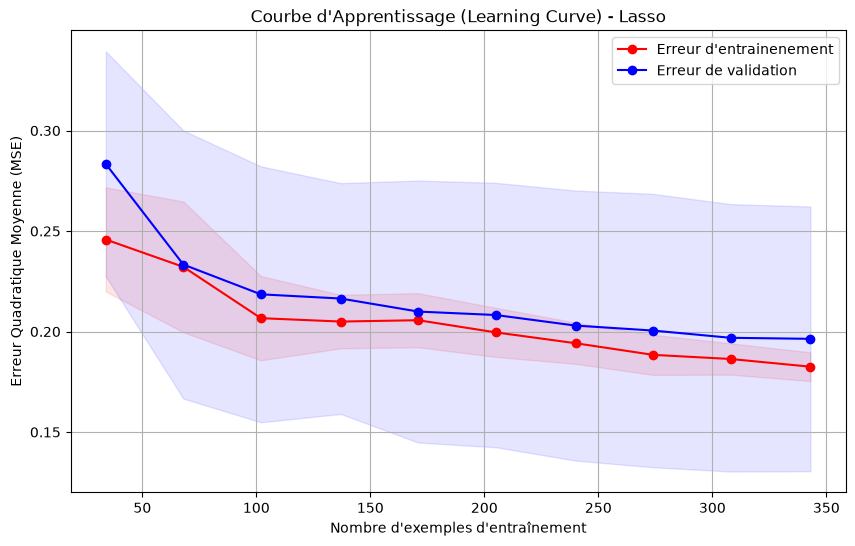

In [16]:
lasso_model = make_pipeline(StandardScaler(), LassoCV(cv=10, random_state=40))

# lasso_model.fit(X_train, y_train)

# lasso_cv = lasso_model[-1]

# alphas = lasso_cv.alphas_
# mse_mean = lasso_cv.mse_path_.mean(axis=1)
# mse_std = lasso_cv.mse_path_.std(axis=1)
# alpha_best = lasso_cv.alpha_

# print(alpha_best)

# plt.figure(figsize=(10, 6))

# plt.semilogx(alphas, lasso_cv.mse_path_, ":", alpha=0.3, label="MSE par pli")
# plt.semilogx(alphas, mse_mean, "b-", linewidth=2, label="MSE mean")

# plt.semilogx(alphas, mse_mean + mse_std, "b--", alpha=0.5)
# plt.semilogx(alphas, mse_mean + mse_std, "b--", alpha=0.5)

# plt.axvline(alpha_best, color="r", linestyle="--", label=f"Meilleur alpha : {alpha_best:.4f}")

# plt.xlabel(r"$\alpha$ Paramètres de régularisation")
# plt.ylabel("Erreur Quadratique Moyenne")
# plt.title("Sélection du modèle Lasso par validation croisée")
# plt.legend()

# plt.grid(True, which="both", ls="-", alpha=0.4)
# plt.tight_layout()
# plt.show()

_learning_curve(model=lasso_model, model_name="Lasso")

### Ridget Model

Fit Time : [0.02295065 0.00900126 0.00566792 0.01809549 0.01672697]

Score Time : [0.00767231 0.01040316 0.00551605 0.03306842 0.01969862]

Test Neg MSE : [-0.29862461 -0.2346449  -0.2073119  -0.18691915 -0.17880967]

Test Neg  MAE : [-0.31292038 -0.37353231 -0.35652329 -0.31659235 -0.35688442]

Test Neg SMSE : [-0.54646556 -0.48440159 -0.45531516 -0.43234148 -0.42285892]

Test R2 : [0.34535839 0.52384318 0.34884646 0.368756   0.4760417 ]


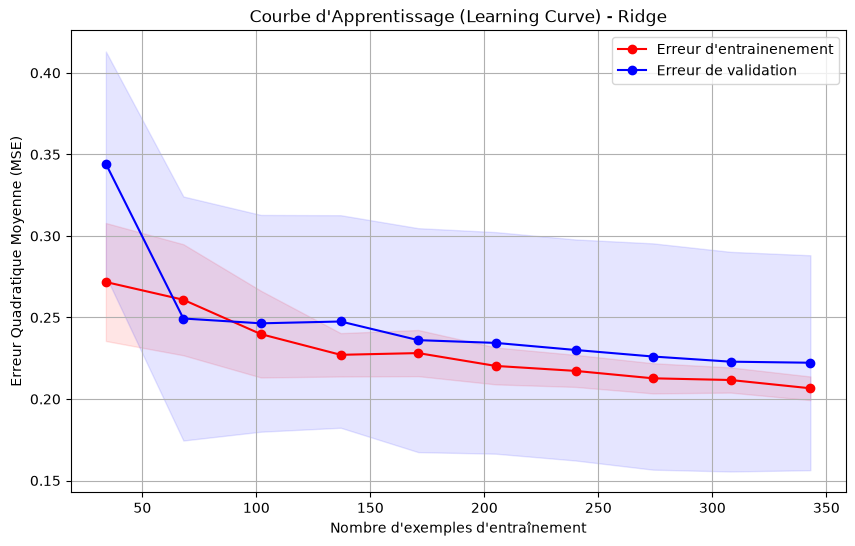

In [17]:
ridge_model = Ridge(alpha=0.1)
ridge_scores = cross_validate(ridge_model, X_train, y_train, scoring=scoring)

print(f"Fit Time : {ridge_scores["fit_time"]}")
print()
print(f"Score Time : {ridge_scores["score_time"]}")
print()
print(f"Test Neg MSE : {ridge_scores["test_neg_mean_squared_error"]}")
print()
print(f"Test Neg  MAE : {ridge_scores["test_neg_median_absolute_error"]}")
print()
print(f"Test Neg SMSE : {ridge_scores["test_neg_root_mean_squared_error"]}")
print()
print(f"Test R2 : {ridge_scores["test_r2"]}")

_learning_curve(model=ridge_model, model_name="Ridge")

### Arbres de décision

Fit Time : [0.00737691 0.00698614 0.00719643 0.00477695 0.00466871]

Score Time : [0.00636768 0.00821304 0.00559878 0.0049212  0.00521541]

Test Neg MSE : [-0.37271734 -0.21222315 -0.2179531  -0.22386697 -0.23855579]

Test Neg  MAE : [-0.29525882 -0.25023537 -0.29071007 -0.29411193 -0.28585409]

Test Neg SMSE : [-0.61050581 -0.46067684 -0.46685447 -0.47314582 -0.48842174]

Test R2 : [0.18293312 0.56934288 0.31542313 0.24397967 0.30097018]


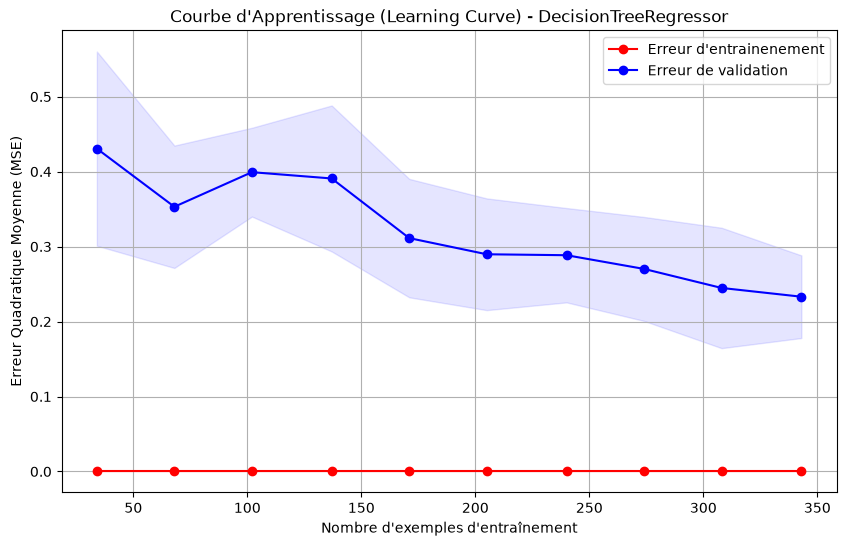

In [18]:
tree_model = DecisionTreeRegressor()
tree_scores = cross_validate(tree_model, X_train, y_train, scoring=scoring)

print(f"Fit Time : {tree_scores["fit_time"]}")
print()
print(f"Score Time : {tree_scores["score_time"]}")
print()
print(f"Test Neg MSE : {tree_scores["test_neg_mean_squared_error"]}")
print()
print(f"Test Neg  MAE : {tree_scores["test_neg_median_absolute_error"]}")
print()
print(f"Test Neg SMSE : {tree_scores["test_neg_root_mean_squared_error"]}")
print()
print(f"Test R2 : {tree_scores["test_r2"]}")

_learning_curve(model=tree_model, model_name="DecisionTreeRegressor")

### Modèle de Fôrets Aléatoire

Fit Time : [0.30044222 0.23260474 0.22788358 0.21619701 0.23025942]

Score Time : [0.02007365 0.01866746 0.02250195 0.01894212 0.02310133]

Test Neg MSE : [-0.20059838 -0.15572353 -0.11845576 -0.09951865 -0.12059169]

Test Neg  MAE : [-0.21790054 -0.25528505 -0.24918832 -0.21159761 -0.25739167]

Test Neg SMSE : [-0.4478821  -0.39461821 -0.34417402 -0.31546576 -0.34726314]

Test R2 : [0.56025043 0.6839956  0.62793797 0.66391594 0.64663533]


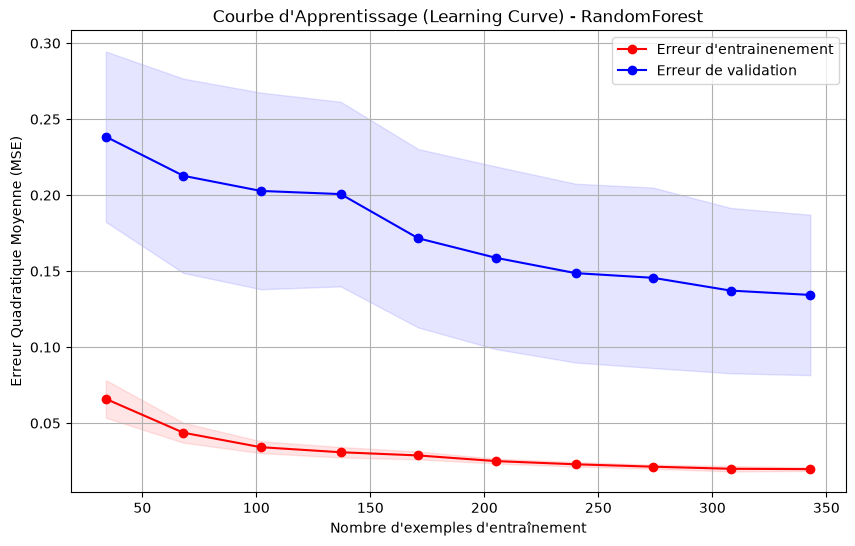

In [20]:
random_model = RandomForestRegressor()

random_scores = cross_validate(random_model, X_train, y_train, scoring=scoring)

print(f"Fit Time : {random_scores["fit_time"]}")
print()
print(f"Score Time : {random_scores["score_time"]}")
print()
print(f"Test Neg MSE : {random_scores["test_neg_mean_squared_error"]}")
print()
print(f"Test Neg  MAE : {random_scores["test_neg_median_absolute_error"]}")
print()
print(f"Test Neg SMSE : {random_scores["test_neg_root_mean_squared_error"]}")
print()
print(f"Test R2 : {random_scores["test_r2"]}")

_learning_curve(model=random_model, model_name="RandomForest")

### Modèle de Gradient Boosting

In [ ]:
param_grid = {
    "n_estimators": np.linspace(50, 500, 5, dtype=int).tolist(),
    "learning_rate": np.logspace(-5, -1, 5).tolist(),
    "max_depth": np.linspace(1, 20, 4, dtype=int).tolist(),
    "subsample": np.linspace(0.5, 1.0, 4).tolist()
}

boosting_model = GradientBoostingRegressor(random_state=42)

search = HalvingGridSearchCV(
    estimator=boosting_model,
    param_grid=param_grid,
    factor=2,
    aggressive_elimination=True,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    random_state=42
)

print("Avant l'entrainement")

search.fit(X_train, y_train)

print("Apres l'entrainement")

print(search.best_score_)
print(search.best_params_)

_learning_curve(model=search.best_estimator_, model_name="GradientBoosting")

print("hello")